Measured from LRGs (optical-selection) rather than randoms

In [1]:
from __future__ import division, print_function
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table, vstack, hstack
import fitsio
import sys, os, glob, time, warnings, gc
import healpy as hp
from scipy import stats
from IPython.display import Image

sys.path.append(os.path.expanduser('~/git/desi-targets/useful'))
from isdes import get_isdes

In [2]:
params = {'legend.fontsize': 'large',
         'axes.labelsize': 'large',
         'axes.titlesize':'large',
         'xtick.labelsize':'large',
         'ytick.labelsize':'large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

--------
# min_nobs = 1 and LRG mask

In [3]:
min_nobs = 1

maskbits = []
apply_lrgmask = True

nside = 128

In [4]:
npix = hp.nside2npix(nside)
pix_area = hp.pixelfunc.nside2pixarea(nside, degrees=True)
print('Healpix size = {:.5f} sq deg'.format(pix_area))

if apply_lrgmask:
    lrgmask_str = '_lrgmask_v1'
else:
    lrgmask_str = ''

randoms_ver_str = '0.49.0'

# randoms_combined_dir = '/global/cfs/cdirs/desi/users/rongpu/data/imaging_sys/randoms_stats/{}/resolve/combined'.format(randoms_ver_str)
randoms_combined_dir = '/Users/rongpu/Documents/Data/desi_targets/dr9.0/imaging_sys/randoms_stats/{}/resolve/combined'.format(randoms_ver_str)

nside = 128

maps_combined = []
for field in ['north', 'south']:
    maps_path = os.path.join(randoms_combined_dir, 'pixmap_{}_nside_{}_minobs_{}_maskbits_{}.fits'.format(field, nside, min_nobs, ''.join([str(tmp) for tmp in maskbits])+lrgmask_str))
    maps = Table.read(os.path.join(maps_path))
    maps = maps[maps['n_randoms']>0]
    maps['field'] = field
    maps_combined.append(maps)
maps = vstack(maps_combined)

maps['isdes'] = get_isdes(maps['RA'], maps['DEC'], nside)

Healpix size = 0.20982 sq deg


In [5]:
des = maps['isdes'].copy()
south = (maps['field']=='south').copy()
decals = south & (~maps['isdes'])
bm = (maps['field']=='north')

median galdepth_gmag_ebv = 24.370
median galdepth_rmag_ebv = 23.807
median galdepth_zmag_ebv = 22.998
median psfdepth_w1mag_ebv = 21.428


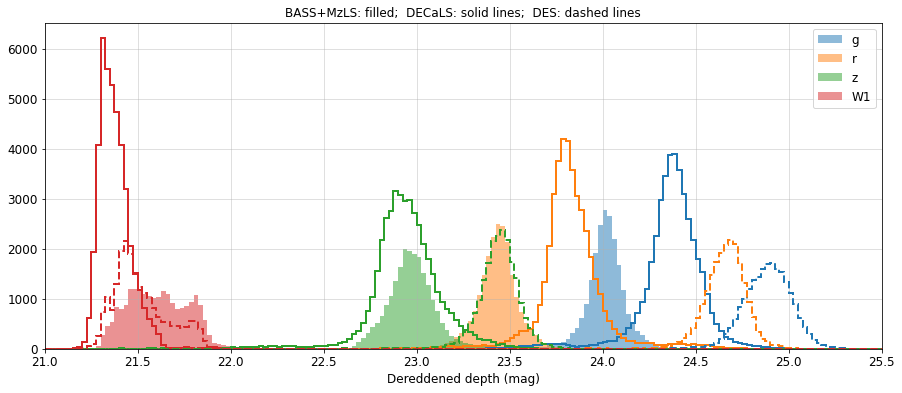

In [6]:
print('median galdepth_gmag_ebv = {:.3f}'.format(np.median(maps['galdepth_gmag_ebv'])))
print('median galdepth_rmag_ebv = {:.3f}'.format(np.median(maps['galdepth_rmag_ebv'])))
print('median galdepth_zmag_ebv = {:.3f}'.format(np.median(maps['galdepth_zmag_ebv'])))
print('median psfdepth_w1mag_ebv = {:.3f}'.format(np.median(maps['psfdepth_w1mag_ebv'])))

plt.figure(figsize=(15, 6))
plt.hist(maps['galdepth_gmag_ebv'][bm], 200, range=(21, 26), weights=maps['FRACAREA'][bm], label='g', color='C0', alpha=0.5)
plt.hist(maps['galdepth_rmag_ebv'][bm], 200, range=(21, 26), weights=maps['FRACAREA'][bm], label='r', color='C1', alpha=0.5)
plt.hist(maps['galdepth_zmag_ebv'][bm], 200, range=(21, 26), weights=maps['FRACAREA'][bm], label='z', color='C2', alpha=0.5)
plt.hist(maps['psfdepth_w1mag_ebv'][bm], 200, range=(21, 26), weights=maps['FRACAREA'][bm], label='W1', color='C3', alpha=0.5)

plt.hist(maps['galdepth_gmag_ebv'][decals], 200, range=(21, 26), weights=maps['FRACAREA'][decals], color='C0', histtype='step', ls='-', lw=2)
plt.hist(maps['galdepth_rmag_ebv'][decals], 200, range=(21, 26), weights=maps['FRACAREA'][decals], color='C1', histtype='step', ls='-', lw=2)
plt.hist(maps['galdepth_zmag_ebv'][decals], 200, range=(21, 26), weights=maps['FRACAREA'][decals], color='C2', histtype='step', ls='-', lw=2)
plt.hist(maps['psfdepth_w1mag_ebv'][decals], 200, range=(21, 26), weights=maps['FRACAREA'][decals], color='C3', histtype='step', ls='-', lw=2)

plt.hist(maps['galdepth_gmag_ebv'][des], 200, range=(21, 26), weights=maps['FRACAREA'][des], color='C0', histtype='step', ls='--', lw=2)
plt.hist(maps['galdepth_rmag_ebv'][des], 200, range=(21, 26), weights=maps['FRACAREA'][des], color='C1', histtype='step', ls='--', lw=2)
plt.hist(maps['galdepth_zmag_ebv'][des], 200, range=(21, 26), weights=maps['FRACAREA'][des], color='C2', histtype='step', ls='--', lw=2)
plt.hist(maps['psfdepth_w1mag_ebv'][des], 200, range=(21, 26), weights=maps['FRACAREA'][des], color='C3', histtype='step', ls='--', lw=2)

plt.xlabel('Dereddened depth (mag)')
plt.title('BASS+MzLS: filled;  DECaLS: solid lines;  DES: dashed lines')
plt.xlim(21., 25.5)
plt.grid(alpha=0.5)
plt.legend()
plt.show()

In [7]:
print('Median 5-sigma galaxy depth in g, r, z and PSF depth in W1 (all depths are dereddened)')
print('DES:')
print('{:.2f}   {:.2f}   {:.2f}   {:.2f}'.format(np.median(maps['galdepth_gmag_ebv'][des]), np.median(maps['galdepth_rmag_ebv'][des]), np.median(maps['galdepth_zmag_ebv'][des]), np.median(maps['psfdepth_w1mag_ebv'][des])))
print('DECaLS:')
print('{:.2f}   {:.2f}   {:.2f}   {:.2f}'.format(np.median(maps['galdepth_gmag_ebv'][decals]), np.median(maps['galdepth_rmag_ebv'][decals]), np.median(maps['galdepth_zmag_ebv'][decals]), np.median(maps['psfdepth_w1mag_ebv'][decals])))
print('BASS/MzLS')
print('{:.2f}   {:.2f}   {:.2f}   {:.2f}'.format(np.median(maps['galdepth_gmag_ebv'][bm]), np.median(maps['galdepth_rmag_ebv'][bm]), np.median(maps['galdepth_zmag_ebv'][bm]), np.median(maps['psfdepth_w1mag_ebv'][bm])))

print()
print('Total area: {:.1f} sq deg'.format(np.sum(maps['FRACAREA']*pix_area)))
print()
print('BASS/MzLS area: {:.1f} sq deg'.format(np.sum(maps['FRACAREA'][bm]*pix_area)))
print('DES+DECaLS area: {:.1f} sq deg'.format(np.sum(maps['FRACAREA'][south]*pix_area)))
print()
print('DES area:       {:.1f} sq deg'.format(np.sum(maps['FRACAREA'][des]*pix_area)))
print('DECaLS area:    {:.1f} sq deg'.format(np.sum(maps['FRACAREA'][decals]*pix_area)))

Median 5-sigma galaxy depth in g, r, z and PSF depth in W1 (all depths are dereddened)
DES:
24.89   24.67   23.45   21.48
DECaLS:
24.38   23.81   22.93   21.37
BASS/MzLS
24.02   23.44   22.97   21.61

Total area: 17996.3 sq deg

BASS/MzLS area: 4525.5 sq deg
DES+DECaLS area: 13470.8 sq deg

DES area:       4439.3 sq deg
DECaLS area:    9031.4 sq deg


In [9]:
print('Median 5-sigma PSF depth in g, r, z and W1 (all depths are dereddened)')
print('DES:')
print('{:.2f}   {:.2f}   {:.2f}   {:.2f}'.format(np.median(maps['psfdepth_gmag_ebv'][des]), np.median(maps['psfdepth_rmag_ebv'][des]), np.median(maps['psfdepth_zmag_ebv'][des]), np.median(maps['psfdepth_w1mag_ebv'][des])))
print('DECaLS:')
print('{:.2f}   {:.2f}   {:.2f}   {:.2f}'.format(np.median(maps['psfdepth_gmag_ebv'][decals]), np.median(maps['psfdepth_rmag_ebv'][decals]), np.median(maps['psfdepth_zmag_ebv'][decals]), np.median(maps['psfdepth_w1mag_ebv'][decals])))
print('BASS/MzLS')
print('{:.2f}   {:.2f}   {:.2f}   {:.2f}'.format(np.median(maps['psfdepth_gmag_ebv'][bm]), np.median(maps['psfdepth_rmag_ebv'][bm]), np.median(maps['psfdepth_zmag_ebv'][bm]), np.median(maps['psfdepth_w1mag_ebv'][bm])))

print()
print('Total area: {:.1f} sq deg'.format(np.sum(maps['FRACAREA']*pix_area)))
print()
print('BASS/MzLS area: {:.1f} sq deg'.format(np.sum(maps['FRACAREA'][bm]*pix_area)))
print('DES+DECaLS area: {:.1f} sq deg'.format(np.sum(maps['FRACAREA'][south]*pix_area)))
print()
print('DES area:       {:.1f} sq deg'.format(np.sum(maps['FRACAREA'][des]*pix_area)))
print('DECaLS area:    {:.1f} sq deg'.format(np.sum(maps['FRACAREA'][decals]*pix_area)))

Median 5-sigma PSF depth in g, r, z and W1 (all depths are dereddened)
DES:
25.16   24.99   23.82   21.48
DECaLS:
24.63   24.10   23.24   21.37
BASS/MzLS
24.19   23.65   23.30   21.61

Total area: 17996.3 sq deg

BASS/MzLS area: 4525.5 sq deg
DES+DECaLS area: 13470.8 sq deg

DES area:       4439.3 sq deg
DECaLS area:    9031.4 sq deg


--------
# min_nobs = 2 and LRG mask

In [10]:
min_nobs = 2

maskbits = []
apply_lrgmask = True

nside = 128

In [11]:
npix = hp.nside2npix(nside)
pix_area = hp.pixelfunc.nside2pixarea(nside, degrees=True)
print('Healpix size = {:.5f} sq deg'.format(pix_area))

if apply_lrgmask:
    lrgmask_str = '_lrgmask_v1'
else:
    lrgmask_str = ''

randoms_ver_str = '0.49.0'

# randoms_combined_dir = '/global/cfs/cdirs/desi/users/rongpu/data/imaging_sys/randoms_stats/{}/resolve/combined'.format(randoms_ver_str)
randoms_combined_dir = '/Users/rongpu/Documents/Data/desi_targets/dr9.0/imaging_sys/randoms_stats/{}/resolve/combined'.format(randoms_ver_str)

nside = 128

maps_combined = []
for field in ['north', 'south']:
    maps_path = os.path.join(randoms_combined_dir, 'pixmap_{}_nside_{}_minobs_{}_maskbits_{}.fits'.format(field, nside, min_nobs, ''.join([str(tmp) for tmp in maskbits])+lrgmask_str))
    maps = Table.read(os.path.join(maps_path))
    maps = maps[maps['n_randoms']>0]
    maps['field'] = field
    maps_combined.append(maps)
maps = vstack(maps_combined)

maps['isdes'] = get_isdes(maps['RA'], maps['DEC'], nside)

Healpix size = 0.20982 sq deg


In [12]:
des = maps['isdes'].copy()
south = (maps['field']=='south').copy()
decals = south & (~maps['isdes'])
bm = (maps['field']=='north')

median galdepth_gmag_ebv = 24.380
median galdepth_rmag_ebv = 23.819
median galdepth_zmag_ebv = 23.007
median psfdepth_w1mag_ebv = 21.429


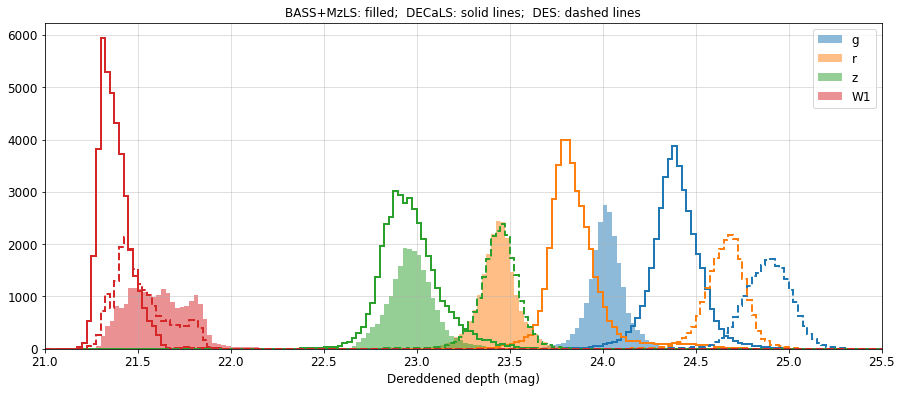

In [13]:
print('median galdepth_gmag_ebv = {:.3f}'.format(np.median(maps['galdepth_gmag_ebv'])))
print('median galdepth_rmag_ebv = {:.3f}'.format(np.median(maps['galdepth_rmag_ebv'])))
print('median galdepth_zmag_ebv = {:.3f}'.format(np.median(maps['galdepth_zmag_ebv'])))
print('median psfdepth_w1mag_ebv = {:.3f}'.format(np.median(maps['psfdepth_w1mag_ebv'])))

plt.figure(figsize=(15, 6))
plt.hist(maps['galdepth_gmag_ebv'][bm], 200, range=(21, 26), weights=maps['FRACAREA'][bm], label='g', color='C0', alpha=0.5)
plt.hist(maps['galdepth_rmag_ebv'][bm], 200, range=(21, 26), weights=maps['FRACAREA'][bm], label='r', color='C1', alpha=0.5)
plt.hist(maps['galdepth_zmag_ebv'][bm], 200, range=(21, 26), weights=maps['FRACAREA'][bm], label='z', color='C2', alpha=0.5)
plt.hist(maps['psfdepth_w1mag_ebv'][bm], 200, range=(21, 26), weights=maps['FRACAREA'][bm], label='W1', color='C3', alpha=0.5)

plt.hist(maps['galdepth_gmag_ebv'][decals], 200, range=(21, 26), weights=maps['FRACAREA'][decals], color='C0', histtype='step', ls='-', lw=2)
plt.hist(maps['galdepth_rmag_ebv'][decals], 200, range=(21, 26), weights=maps['FRACAREA'][decals], color='C1', histtype='step', ls='-', lw=2)
plt.hist(maps['galdepth_zmag_ebv'][decals], 200, range=(21, 26), weights=maps['FRACAREA'][decals], color='C2', histtype='step', ls='-', lw=2)
plt.hist(maps['psfdepth_w1mag_ebv'][decals], 200, range=(21, 26), weights=maps['FRACAREA'][decals], color='C3', histtype='step', ls='-', lw=2)

plt.hist(maps['galdepth_gmag_ebv'][des], 200, range=(21, 26), weights=maps['FRACAREA'][des], color='C0', histtype='step', ls='--', lw=2)
plt.hist(maps['galdepth_rmag_ebv'][des], 200, range=(21, 26), weights=maps['FRACAREA'][des], color='C1', histtype='step', ls='--', lw=2)
plt.hist(maps['galdepth_zmag_ebv'][des], 200, range=(21, 26), weights=maps['FRACAREA'][des], color='C2', histtype='step', ls='--', lw=2)
plt.hist(maps['psfdepth_w1mag_ebv'][des], 200, range=(21, 26), weights=maps['FRACAREA'][des], color='C3', histtype='step', ls='--', lw=2)

plt.xlabel('Dereddened depth (mag)')
plt.title('BASS+MzLS: filled;  DECaLS: solid lines;  DES: dashed lines')
plt.xlim(21., 25.5)
plt.grid(alpha=0.5)
plt.legend()
plt.show()

In [14]:
print('Median 5-sigma galaxy depth in g, r, z and PSF depth in W1 (all depths are dereddened)')
print('DES:')
print('{:.2f}   {:.2f}   {:.2f}   {:.2f}'.format(np.median(maps['galdepth_gmag_ebv'][des]), np.median(maps['galdepth_rmag_ebv'][des]), np.median(maps['galdepth_zmag_ebv'][des]), np.median(maps['psfdepth_w1mag_ebv'][des])))
print('DECaLS:')
print('{:.2f}   {:.2f}   {:.2f}   {:.2f}'.format(np.median(maps['galdepth_gmag_ebv'][decals]), np.median(maps['galdepth_rmag_ebv'][decals]), np.median(maps['galdepth_zmag_ebv'][decals]), np.median(maps['psfdepth_w1mag_ebv'][decals])))
print('BASS/MzLS')
print('{:.2f}   {:.2f}   {:.2f}   {:.2f}'.format(np.median(maps['galdepth_gmag_ebv'][bm]), np.median(maps['galdepth_rmag_ebv'][bm]), np.median(maps['galdepth_zmag_ebv'][bm]), np.median(maps['psfdepth_w1mag_ebv'][bm])))

print()
print('Total area: {:.1f} sq deg'.format(np.sum(maps['FRACAREA']*pix_area)))
print()
print('BASS/MzLS area: {:.1f} sq deg'.format(np.sum(maps['FRACAREA'][bm]*pix_area)))
print('DES+DECaLS area: {:.1f} sq deg'.format(np.sum(maps['FRACAREA'][south]*pix_area)))
print()
print('DES area:       {:.1f} sq deg'.format(np.sum(maps['FRACAREA'][des]*pix_area)))
print('DECaLS area:    {:.1f} sq deg'.format(np.sum(maps['FRACAREA'][decals]*pix_area)))

Median 5-sigma galaxy depth in g, r, z and PSF depth in W1 (all depths are dereddened)
DES:
24.89   24.67   23.45   21.48
DECaLS:
24.39   23.82   22.95   21.36
BASS/MzLS
24.02   23.44   22.97   21.61

Total area: 17228.8 sq deg

BASS/MzLS area: 4406.4 sq deg
DES+DECaLS area: 12822.4 sq deg

DES area:       4432.0 sq deg
DECaLS area:    8390.4 sq deg


In [15]:
print('Median 5-sigma PSF depth in g, r, z and W1 (all depths are dereddened)')
print('DES:')
print('{:.2f}   {:.2f}   {:.2f}   {:.2f}'.format(np.median(maps['psfdepth_gmag_ebv'][des]), np.median(maps['psfdepth_rmag_ebv'][des]), np.median(maps['psfdepth_zmag_ebv'][des]), np.median(maps['psfdepth_w1mag_ebv'][des])))
print('DECaLS:')
print('{:.2f}   {:.2f}   {:.2f}   {:.2f}'.format(np.median(maps['psfdepth_gmag_ebv'][decals]), np.median(maps['psfdepth_rmag_ebv'][decals]), np.median(maps['psfdepth_zmag_ebv'][decals]), np.median(maps['psfdepth_w1mag_ebv'][decals])))
print('BASS/MzLS')
print('{:.2f}   {:.2f}   {:.2f}   {:.2f}'.format(np.median(maps['psfdepth_gmag_ebv'][bm]), np.median(maps['psfdepth_rmag_ebv'][bm]), np.median(maps['psfdepth_zmag_ebv'][bm]), np.median(maps['psfdepth_w1mag_ebv'][bm])))

print()
print('Total area: {:.1f} sq deg'.format(np.sum(maps['FRACAREA']*pix_area)))
print()
print('BASS/MzLS area: {:.1f} sq deg'.format(np.sum(maps['FRACAREA'][bm]*pix_area)))
print('DES+DECaLS area: {:.1f} sq deg'.format(np.sum(maps['FRACAREA'][south]*pix_area)))
print()
print('DES area:       {:.1f} sq deg'.format(np.sum(maps['FRACAREA'][des]*pix_area)))
print('DECaLS area:    {:.1f} sq deg'.format(np.sum(maps['FRACAREA'][decals]*pix_area)))

Median 5-sigma PSF depth in g, r, z and W1 (all depths are dereddened)
DES:
25.16   24.99   23.82   21.48
DECaLS:
24.64   24.11   23.25   21.36
BASS/MzLS
24.19   23.65   23.30   21.61

Total area: 17228.8 sq deg

BASS/MzLS area: 4406.4 sq deg
DES+DECaLS area: 12822.4 sq deg

DES area:       4432.0 sq deg
DECaLS area:    8390.4 sq deg
